# 01 — Preprocessing Pipeline Demo
This notebook walks through each stage of the BGT image preprocessing pipeline visually.

In [126]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.morphology import skeletonize



In [127]:

# utils

def display_img(img):
  plt.imshow(img, cmap='gray')
  plt.axis("off")
  plt.show()

def upload_img(title, img):
    cv2.imwrite(title, img)

## Convet to grayscale

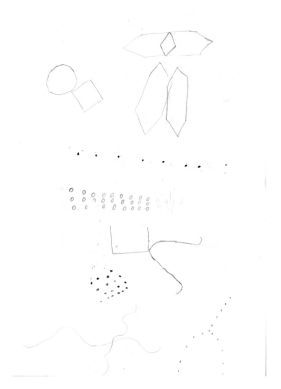

(1755, 1241, 3)


In [144]:
img = cv2.imread(r"F:\Github\bender-gestalt-analysis\data\raw_drawings\page-0001.jpg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

display_img(gray)
upload_img(r"F:\Github\bender-gestalt-analysis\notebooks\tests\gray.jpg",gray)
print(img.shape)



## Denoised (Noise Removal)

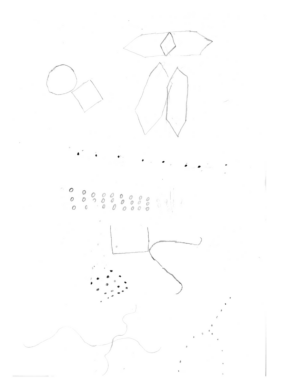

In [129]:
denoise = cv2.GaussianBlur(gray, (5, 5), 0)
display_img(denoise)
upload_img(r"tests\denoised.jpg",denoise)



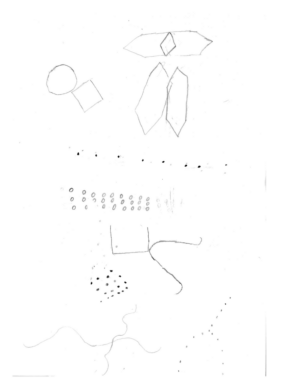

In [130]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(denoise)

display_img(enhanced)
upload_img(r"tests\enhanced.jpg",enhanced)



## Segmentation using Threshold

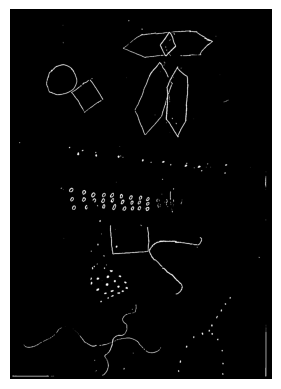

In [131]:
thresh = cv2.adaptiveThreshold(
    enhanced,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    21,
    10
)

display_img(thresh)
upload_img(r"tests\thresh.jpg",thresh)



more accurate after segmentation by threshold

## Morphological (using Erosion)

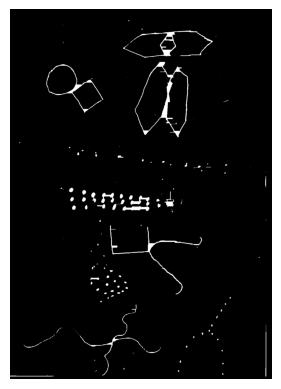

In [137]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

clean = cv2.morphologyEx(
    thresh,
    cv2.MORPH_CLOSE,
    kernel
)

# 1) Close gaps between neighboring dots
kernel_dots = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (25, 7)   # width > height to connect dots in a row
)

dots_connected = cv2.morphologyEx(
    clean,
    cv2.MORPH_CLOSE,
    kernel_dots,
    iterations=1
)

display_img(dots_connected)
# upload_img(r"tests\clean.jpg",clean)


## Skeletonizer

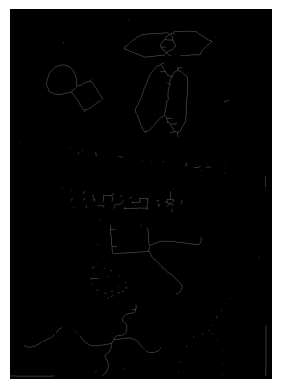

In [138]:
skeleton = skeletonize(dots_connected // 255)
skeleton = (skeleton * 255).astype("uint8")


display_img(skeleton)
# upload_img(r"tests\skeleton.jpg",skeleton)


## Find Contours

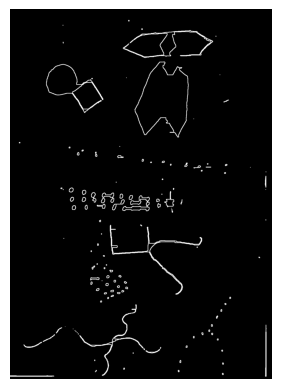

In [141]:
# find contours
contours, _ = cv2.findContours(
    dots_connected,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# create blank image
contour_img = np.zeros_like(clean)

# draw contours
cv2.drawContours(
    contour_img,
    contours,
    -1,
    255,
    2
)

display_img(contour_img)
upload_img(r"tests\contours.jpg",contour_img)


Area = 440.5
Perimeter = 421.0710676908493
Aspect Ratio = 52.25
------------------------------
Area = 166.0
Perimeter = 153.0538226366043
Aspect Ratio = 3.7222222222222223
------------------------------
Area = 159.0
Perimeter = 201.33809328079224
Aspect Ratio = 3.3076923076923075
------------------------------
Area = 463.0
Perimeter = 493.3137083053589
Aspect Ratio = 0.02040816326530612
------------------------------
Area = 1929.5
Perimeter = 1655.6336798667908
Aspect Ratio = 0.8931750741839762
------------------------------
Area = 50.0
Perimeter = 33.3137081861496
Aspect Ratio = 1.625
------------------------------
Area = 57.5
Perimeter = 31.899494767189026
Aspect Ratio = 1.5
------------------------------
Area = 68.5
Perimeter = 35.071067571640015
Aspect Ratio = 2.0
------------------------------
Area = 56.5
Perimeter = 30.727921724319458
Aspect Ratio = 1.2222222222222223
------------------------------
Area = 85.5
Perimeter = 39.071067690849304
Aspect Ratio = 1.5555555555555556
-----

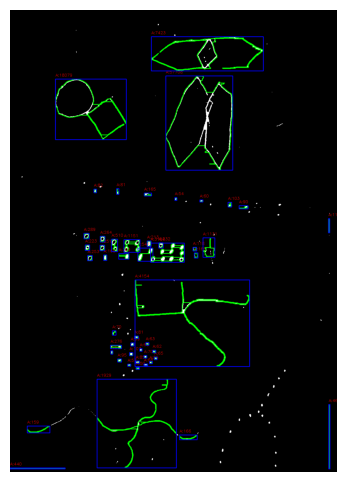

In [142]:
# copy image for drawing features
feature_img = cv2.cvtColor(clean, cv2.COLOR_GRAY2BGR)

for cnt in contours:

    # ignore tiny noise
    area = cv2.contourArea(cnt)

    if area < 50:
        continue

    # perimeter
    perimeter = cv2.arcLength(cnt, True)

    # bounding box
    x, y, w, h = cv2.boundingRect(cnt)

    # aspect ratio
    aspect_ratio = w / h

    # draw contour
    cv2.drawContours(feature_img, [cnt], -1, (0,255,0), 2)

    # draw rectangle
    cv2.rectangle(
        feature_img,
        (x, y),
        (x+w, y+h),
        (255,0,0),
        2
    )

    # print info on image
    cv2.putText(
        feature_img,
        f"A:{int(area)}",
        (x, y-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0,0,255),
        1
    )

    print("Area =", area)
    print("Perimeter =", perimeter)
    print("Aspect Ratio =", aspect_ratio)
    print("-"*30)

# show final image
plt.figure(figsize=(6,6))

plt.imshow(cv2.cvtColor(feature_img, cv2.COLOR_BGR2RGB))

plt.axis("off")
plt.show()

upload_img(r"tests\features.jpg",feature_img)




Rotation Angle = -90.0
Rotation Angle = -5.273896217346191
Rotation Angle = -8.32564926147461
Rotation Angle = -90.0
Rotation Angle = -28.761157989501953
Rotation Angle = -7.125016212463379
Rotation Angle = -90.0
Rotation Angle = -90.0
Rotation Angle = -90.0
Rotation Angle = -90.0
Rotation Angle = -45.0
Rotation Angle = -80.53768157958984
Rotation Angle = -90.0
Rotation Angle = -90.0
Rotation Angle = -90.0
Rotation Angle = -53.130104064941406
Rotation Angle = -90.0
Rotation Angle = -1.7899105548858643
Rotation Angle = -90.0
Rotation Angle = -45.0
Rotation Angle = -84.2894058227539
Rotation Angle = -52.12501525878906
Rotation Angle = -67.98416137695312
Rotation Angle = -90.0
Rotation Angle = -90.0
Rotation Angle = -90.0
Rotation Angle = -90.0
Rotation Angle = -34.695152282714844
Rotation Angle = -90.0
Rotation Angle = -71.56504821777344
Rotation Angle = -63.4349479675293
Rotation Angle = -89.45948791503906
Rotation Angle = -90.0
Rotation Angle = -84.2894058227539
Rotation Angle = -90.0


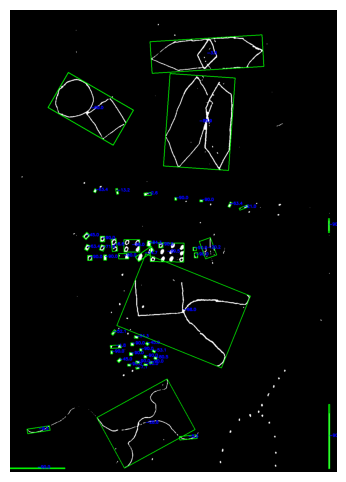

In [143]:
feature_img = cv2.cvtColor(clean, cv2.COLOR_GRAY2BGR)

for cnt in contours:

    area = cv2.contourArea(cnt)

    if area < 50:
        continue

    # rotated rectangle
    rect = cv2.minAreaRect(cnt)

    angle = rect[-1]

    # get rectangle points
    box = cv2.boxPoints(rect)

    box = np.int32(box)

    # draw rotated rectangle
    cv2.drawContours(
        feature_img,
        [box],
        0,
        (0,255,0),
        2
    )

    # center point
    center = (int(rect[0][0]), int(rect[0][1]))

    # write angle
    cv2.putText(
        feature_img,
        f"{angle:.1f}",
        center,
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255,0,0),
        2
    )

    print("Rotation Angle =", angle)

# display
plt.figure(figsize=(6,6))

plt.imshow(cv2.cvtColor(feature_img, cv2.COLOR_BGR2RGB))

plt.axis("off")
plt.show()

# upload_img(r"tests\feature.jpg",feature_img)
